# 漏斗分析 & 同期群留存

**业务问题**：用户在哪个环节流失最多？不同批次用户的留存率有什么规律？

**方法**：SQL 驱动的多步漏斗 + 同期群留存矩阵

In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import sqlite3
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ── 先把 seaborn 风格设好 ──
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

# ── 再设中文字体（必须放在 sns.set_style 之后！否则会被覆盖）──
import matplotlib.font_manager as fm
import glob
_cache_dir = matplotlib.get_cachedir()
for _f in glob.glob(os.path.join(_cache_dir, 'fontlist*.json')):
    try: os.remove(_f)
    except: pass
fm._load_fontmanager(try_read_cache=False)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Noto Sans SC']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

from src.analysis import run_funnel_analysis, cohort_retention_pivot

## 1. 漏斗分析

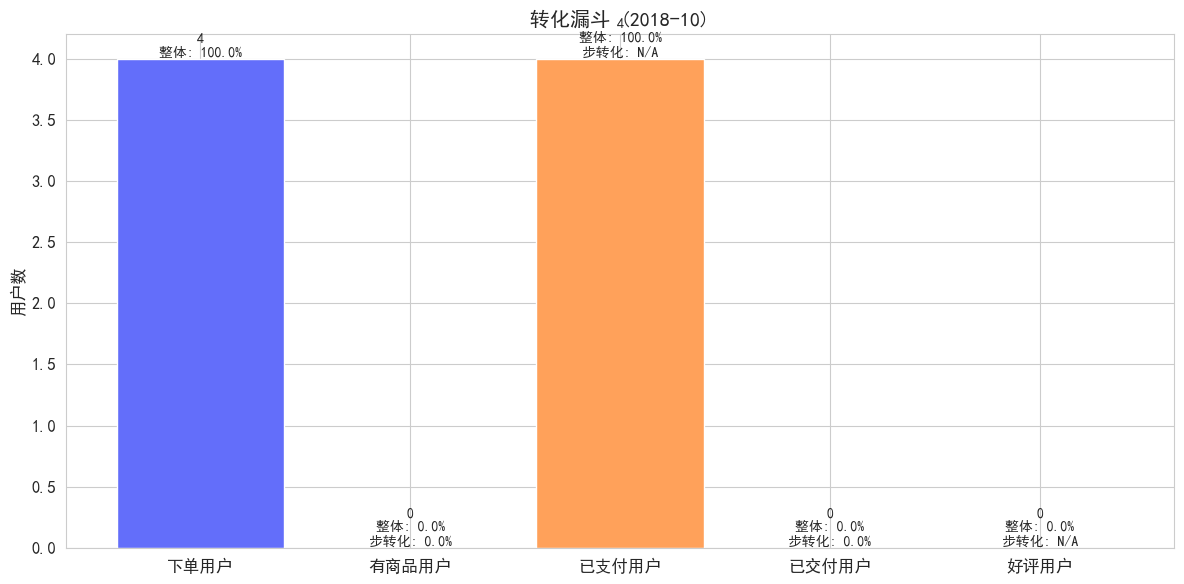

In [3]:
funnel = run_funnel_analysis()

# 最新月漏斗
latest = funnel.tail(1).iloc[0]
steps = [
    ('下单用户', int(latest['下单用户数'])),
    ('有商品用户', int(latest['有商品用户数'])),
    ('已支付用户', int(latest['已支付用户数'])),
    ('已交付用户', int(latest['已交付用户数'])),
    ('好评用户', int(latest['好评用户数'])),
]

labels = [s[0] for s in steps]
values = [s[1] for s in steps]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(labels, values, color=['#636EFA', '#00CC96', '#FFA15A', '#AB63FA', '#EF553B'])

for i, (label, val) in enumerate(zip(labels, values)):
    pct = f'{val/values[0]*100:.1f}%' if values[0] > 0 else 'N/A'
    if i > 0:
        if values[i-1] > 0:
            step_cvr = f'{val/values[i-1]*100:.1f}%'
        else:
            step_cvr = 'N/A'
        ax.annotate(f'{val:,}\n整体: {pct}\n步转化: {step_cvr}',
                   xy=(i, val), ha='center', va='bottom', fontsize=10)
    else:
        ax.annotate(f'{val:,}\n整体: {pct}',
                   xy=(i, val), ha='center', va='bottom', fontsize=10)

ax.set_title(f'转化漏斗 ({latest["月份"]})')
ax.set_ylabel('用户数')
plt.tight_layout()
plt.show()

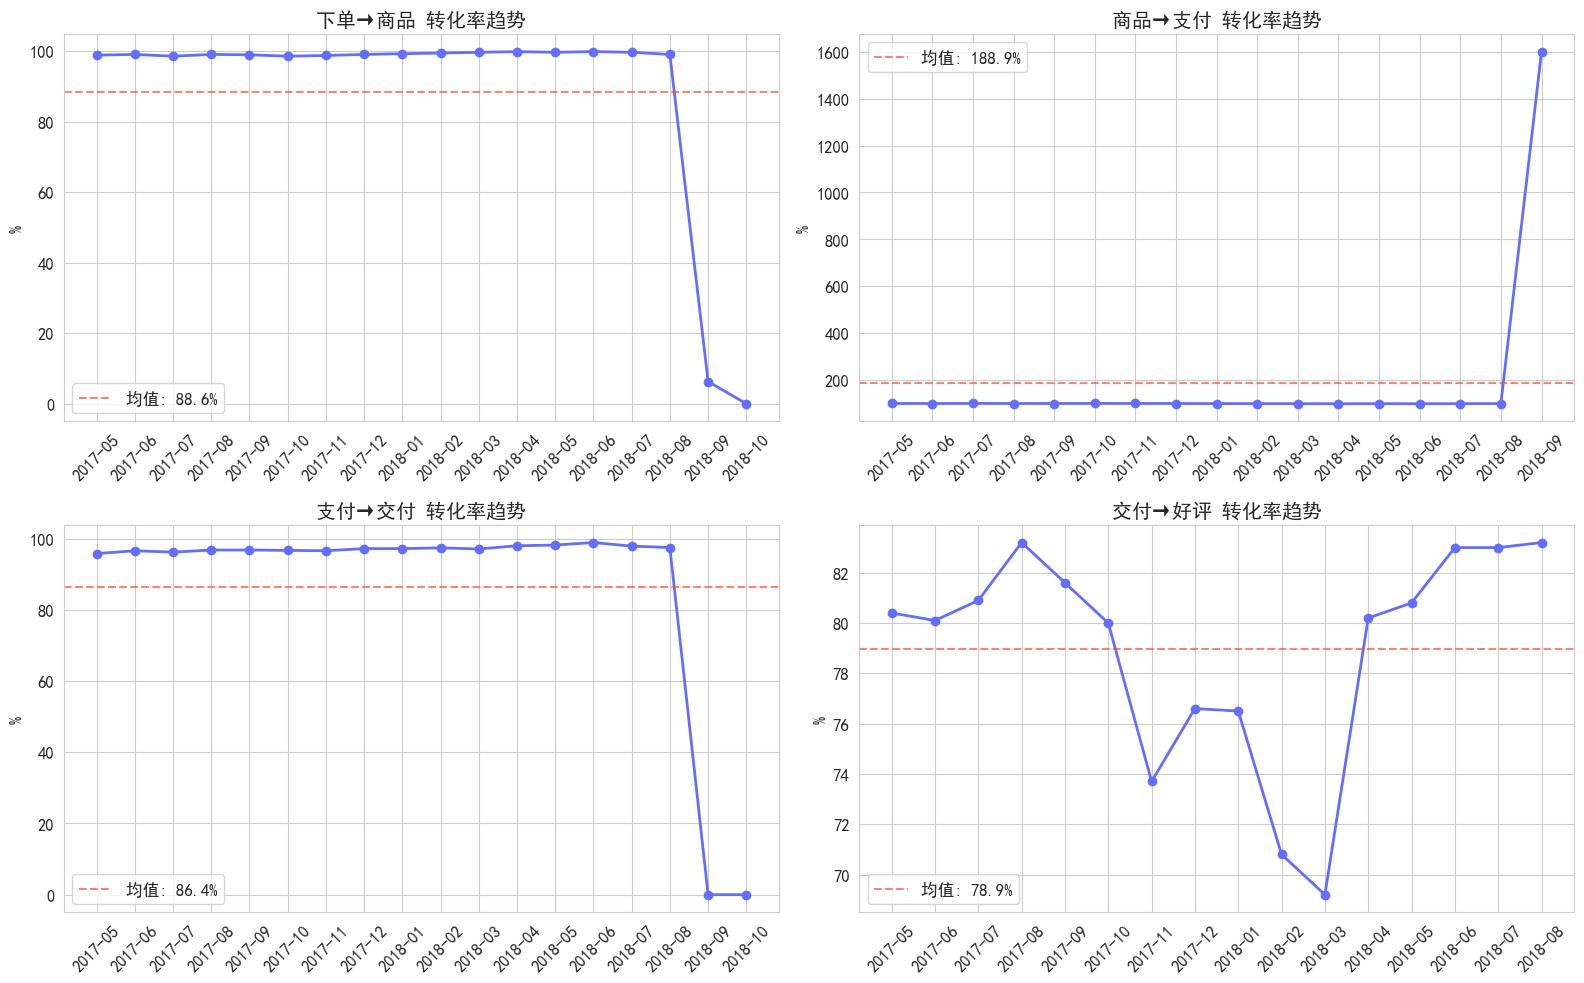

In [9]:
# 逐月转化率变化
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics = ['下单到商品转化率', '商品到支付转化率', '支付到交付转化率', '交付到好评转化率']
titles = ['下单→商品', '商品→支付', '支付→交付', '交付→好评']

for ax, metric, title in zip(axes.flat, metrics, titles):
    ax.plot(funnel['月份'], funnel[metric], 'o-', color='#636EFA', linewidth=2, markersize=6)
    ax.set_title(f'{title} 转化率趋势')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=45)
    avg = funnel[metric].mean()
    ax.axhline(y=avg, color='#EF553B', linestyle='--', alpha=0.7, label=f'均值: {avg:.1f}%')
    ax.legend()

plt.tight_layout()
plt.show()

**关键发现**：最大的转化损失发生在哪个环节？环比是否有恶化趋势？

**业务建议**：针对转化率最低的环节做 A/B 测试优化。

## 2. 卖家同期群留存

> **数据说明**：Olist 数据集客户无复购（每客户仅 1 单），因此留存分析改用卖家维度。
> 卖家在平台上持续接单是 marketplace 健康度的核心指标。

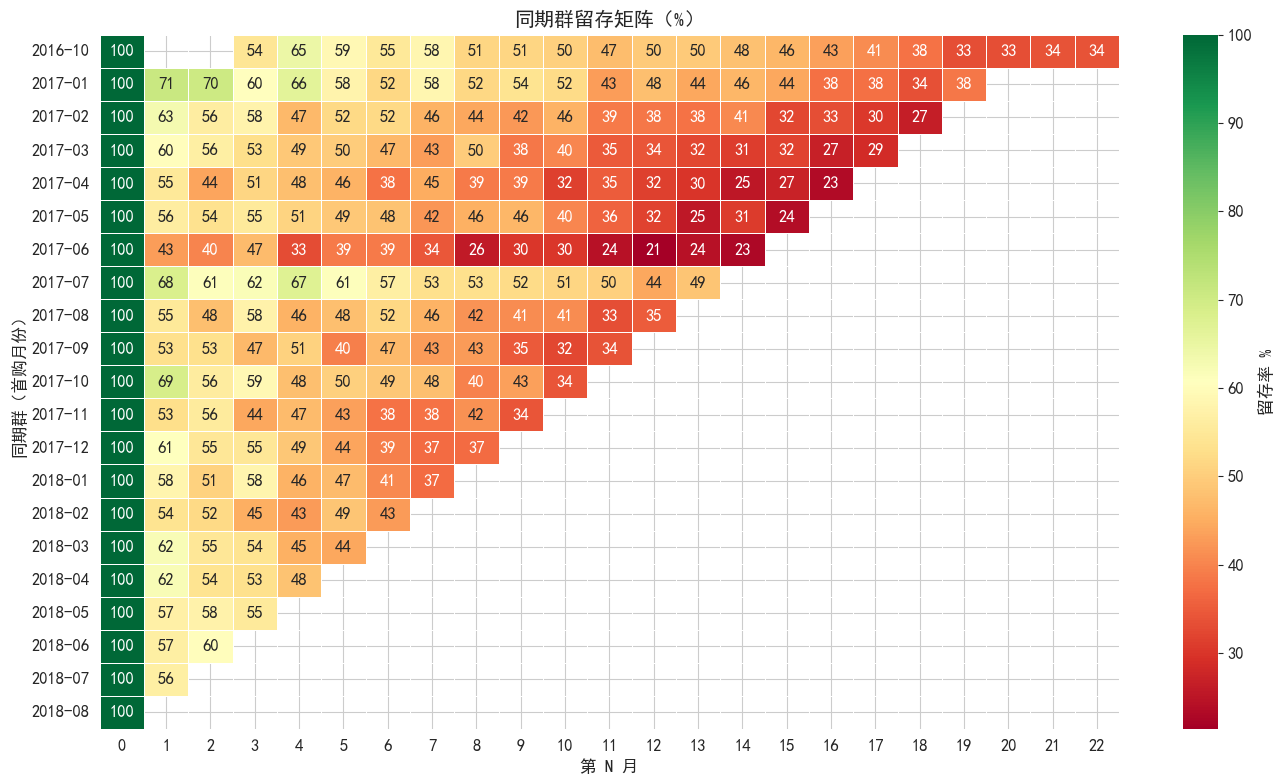

In [5]:
pivot = cohort_retention_pivot()

# 热力图
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax,
            cbar_kws={'label': '留存率 %'}, linewidths=0.5)
ax.set_title('同期群留存矩阵（%）')
ax.set_ylabel('同期群（首购月份）')
ax.set_xlabel('第 N 月')
plt.tight_layout()
plt.show()

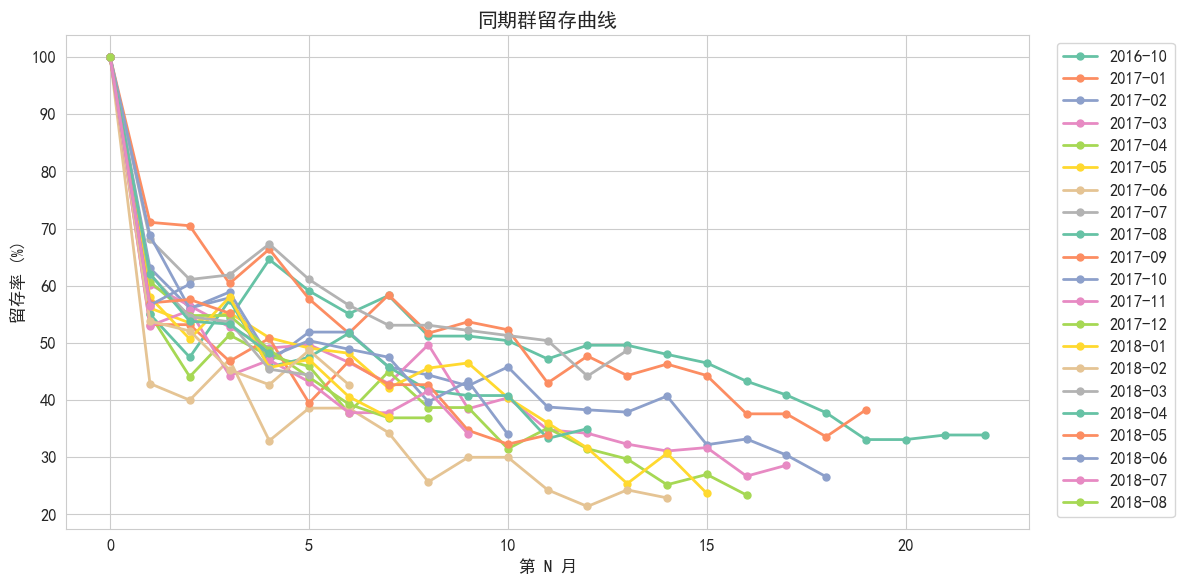

In [6]:
# 留存曲线
fig, ax = plt.subplots(figsize=(12, 6))
for idx, row in pivot.iterrows():
    ax.plot(row.index, row.values, 'o-', linewidth=2, markersize=5, label=idx)
ax.set_xlabel('第 N 月')
ax.set_ylabel('留存率 (%)')
ax.set_title('同期群留存曲线')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**关键发现**：

1. **第 1 月卖家留存约 55-71%**，显著好于一般电商用户留存（通常 20-30%），说明卖家有持续经营动力
2. **留存衰减是渐进式的**，而非断崖——每个月约流失 5-10% 的卖家，到第 12 个月仍有 35-50%
3. **早期同期群（2016-10）留存更持久**，第 22 个月仍有 34%，可能因为：
   - 早期入驻的卖家质量更高 / 更认真经营
   - 平台初期竞争少，老卖家积累了评价优势
4. **2017-06 同期群异常**，第 1 月留存仅 43%（远低于其他批次的 55-71%），值得排查是否该批次有特殊事件（如平台政策变化、季节性因素）